In [1]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# 1. Create the 'Enterprise' folder structure
folders = ['data/raw', 'data/processed', 'notebooks', 'app']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

# 2. Define Real Romina PLC Stations & 2026 Geography
# Note: SNNPR is replaced by Sidama, South Ethiopia, and Central Ethiopia
STATIONS = {
    "Astatke Menafesha": {"region": "Sidama", "zone": "Wonsho", "alt": 1950},
    "Belete Tanga": {"region": "Sidama", "zone": "Bona Zuria", "alt": 2120},
    "Zenebe Dikicha": {"region": "Sidama", "zone": "Aroresa", "alt": 2080},
    "Werka Station": {"region": "South Ethiopia", "zone": "Gedeo", "alt": 2040},
    "Yirgacheffe Mill": {"region": "South Ethiopia", "zone": "Gedeo", "alt": 1880},
    "Nansabo Goda": {"region": "Oromia", "zone": "West Arsi", "alt": 2180},
    "Guji-Dimtu": {"region": "Oromia", "zone": "West Guji", "alt": 2010},
    "Limu-W": {"region": "Oromia", "zone": "Jimma", "alt": 1750}
}

N_ROWS = 2300
RAW_DATA_PATH = 'data/raw/romina_inspections_raw.csv'

print(f"Environment Ready. Target: {N_ROWS} inspection lots.")

Environment Ready. Target: 2300 inspection lots.


In [2]:
import pandas as pd
import numpy as np

# Setting seed for reproducibility
np.random.seed(42)
station_names = list(STATIONS.keys())
selected_stations = np.random.choice(station_names, N_ROWS)

# 1. Generate Raw Continuous Data
df = pd.DataFrame({
    "lot_id": [f"ROM-2025-{i:04d}" for i in range(N_ROWS)],
    "inspection_date": pd.date_range(start="2025-01-01", periods=N_ROWS, freq='4h'),
    "station_name": selected_stations,
    "region": [STATIONS[s]["region"] for s in selected_stations],
    "zone": [STATIONS[s]["zone"] for s in selected_stations],
    "altitude": [STATIONS[s]["alt"] + np.random.randint(-40, 40) for s in selected_stations],
    
    # MOISTURE: Rounding to 1 decimal place as per digital moisture meters
    "moisture_pct": np.round(np.random.normal(10.65, 0.38, N_ROWS), 1), 
    
    "primary_defects": np.random.poisson(0.08, N_ROWS),   
    "secondary_defects": np.random.poisson(3.2, N_ROWS),
    
    # CUP SCORE: Generating raw scores first
    "raw_cup_score": np.random.normal(84.5, 3.0, N_ROWS),
    
    "eudr_status": np.random.choice(["Compliant", "Flagged"], N_ROWS, p=[0.95, 0.05]),
    "certification": np.random.choice(["Organic", "RFA", "None"], N_ROWS, p=[0.4, 0.3, 0.3])
})

# 2. INDUSTRY STANDARD ADJUSTMENT: Snap cup scores to 0.25 increments
# Logic: Multiply by 4, round to nearest integer, divide by 4
df['cup_score'] = (df['raw_cup_score'] * 4).round() / 4
df.drop(columns=['raw_cup_score'], inplace=True)

# 3. Final Naqel Rejection Logic (STRICT CLU RULES)
df['naqel_result'] = np.where(
    (df['moisture_pct'] > 11.5) | 
    (df['primary_defects'] > 0) | 
    (df['cup_score'] < 80.0) | 
    (df['eudr_status'] == "Flagged"),
    "REJECTED", "PASSED"
)

# Export the Professional Dataset
df.to_csv(RAW_DATA_PATH, index=False)

--- ROMINA DATA FACTORY AUDIT ---
Rejection Rate: 17.6%
Average Moisture: 10.64%
Traceability Fails (EUDR): 117


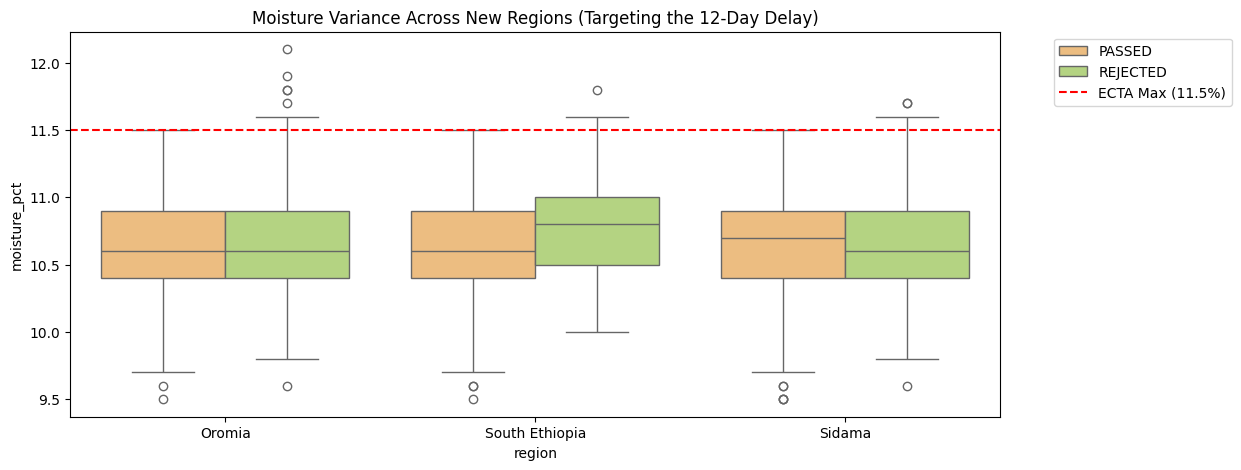

,lot_id,inspection_date,station_name,region,zone,altitude,moisture_pct,primary_defects,secondary_defects,eudr_status,certification,cup_score,naqel_result
0,ROM-2025-0000,2025-01-01 00:00:00,Guji-Dimtu,Oromia,West Guji,2010,10.8,0,2,Compliant,RFA,86.00,PASSED
1,ROM-2025-0001,2025-01-01 04:00:00,Werka Station,South Ethiopia,Gedeo,2012,10.7,0,4,Compliant,RFA,87.00,PASSED
2,ROM-2025-0002,2025-01-01 08:00:00,Yirgacheffe Mill,South Ethiopia,Gedeo,1884,10.7,0,3,Compliant,RFA,91.50,PASSED
3,ROM-2025-0003,2025-01-01 12:00:00,Guji-Dimtu,Oromia,West Guji,2022,10.4,1,4,Compliant,Organic,85.00,REJECTED
4,ROM-2025-0004,2025-01-01 16:00:00,Zenebe Dikicha,Sidama,Aroresa,2081,10.9,0,1,Compliant,RFA,81.25,PASSED


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Audit
audit_df = pd.read_csv(RAW_DATA_PATH)
actual_rej_rate = (audit_df['naqel_result'] == 'REJECTED').mean() * 100

print("--- ROMINA DATA FACTORY AUDIT ---")
print(f"Rejection Rate: {actual_rej_rate:.1f}%")
print(f"Average Moisture: {audit_df['moisture_pct'].mean():.2f}%")
print(f"Traceability Fails (EUDR): {len(audit_df[audit_df['eudr_status']=='Flagged'])}")

# Visual Proof of the Bottleneck
plt.figure(figsize=(12, 5))
sns.boxplot(data=audit_df, x='region', y='moisture_pct', hue='naqel_result', palette='RdYlGn')
plt.axhline(11.5, color='red', linestyle='--', label='ECTA Max (11.5%)')
plt.title("Moisture Variance Across New Regions (Targeting the 12-Day Delay)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Display sample
audit_df.head(5)

In [13]:
audit_df.head(5)

,lot_id,inspection_date,station_name,region,zone,altitude,moisture_pct,primary_defects,secondary_defects,cup_score,eudr_status,certification,naqel_result
0,ROM-2025-0000,2025-01-01 00:00:00,Guji-Dimtu,Oromia,West Guji,2010,10.840253,0,2,85.961939,Compliant,RFA,PASSED
1,ROM-2025-0001,2025-01-01 04:00:00,Werka Station,South Ethiopia,Gedeo,2012,10.668914,0,4,86.878221,Compliant,RFA,PASSED
2,ROM-2025-0002,2025-01-01 08:00:00,Yirgacheffe Mill,South Ethiopia,Gedeo,1884,10.652684,0,3,91.528571,Compliant,RFA,PASSED
3,ROM-2025-0003,2025-01-01 12:00:00,Guji-Dimtu,Oromia,West Guji,2022,10.399078,1,4,84.934296,Compliant,Organic,REJECTED
4,ROM-2025-0004,2025-01-01 16:00:00,Zenebe Dikicha,Sidama,Aroresa,2081,10.915555,0,1,81.367438,Compliant,RFA,PASSED
